In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [19]:
# loading data
messages = pd.read_csv(
    "CollegeMsg.txt",
    sep=" ",
    header=None,
    names=["sender", "receiver", "timestamp"]
)

messages.head()

,sender,receiver,timestamp
0,1,2,1082040961
1,3,4,1082155839
2,5,2,1082414391
3,6,7,1082439619
4,8,7,1082439756


In [20]:
# inspecting data
print("Shape:", messages.shape)
messages.info()

Shape: (59835, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59835 entries, 0 to 59834
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sender     59835 non-null  int64
 1   receiver   59835 non-null  int64
 2   timestamp  59835 non-null  int64
dtypes: int64(3)
memory usage: 1.4 MB


In [7]:
print("Missing values:")
print(messages.isnull().sum())

print("\nExact duplicate rows:", messages.duplicated().sum())

print("\nUnique users:", len(set(messages["sender"]) | set(messages["receiver"])))

Missing values:
sender       0
receiver     0
timestamp    0
dtype: int64

Exact duplicate rows: 37

Unique users: 1899


In [9]:
messages["date"] = pd.to_datetime(messages["timestamp"], unit="s")

print("First message:", messages["date"].min())
print("Last message:", messages["date"].max())
print("Number of messages:", len(messages))

First message: 2004-04-15 14:56:01
Last message: 2004-10-26 07:52:22
Number of messages: 59835


In [22]:
# building full directed network

G = nx.from_pandas_edgelist(
    messages,
    source="sender",
    target="receiver",
    create_using=nx.MultiDiGraph()
)

print("Nodes:", G.number_of_nodes())
print("Messages/edges:", G.number_of_edges())


Nodes: 1899
Messages/edges: 59835


In [18]:
# identify active communicators
sent_counts = messages.groupby("sender").size().sort_values(ascending=False)

active_senders = sent_counts[sent_counts >= 50].index

print("Number of users who sent at least 50 messages:", len(active_senders))

Number of users who sent at least 50 messages: 298


In [12]:
active_messages = messages[
    messages["sender"].isin(active_senders) |
    messages["receiver"].isin(active_senders)
].copy()

print("Messages in active subnetwork:", len(active_messages))

Messages in active subnetwork: 54947


In [24]:
# building active-user network
G_active = nx.from_pandas_edgelist(
    active_messages,
    source="sender",
    target="receiver",
    create_using=nx.MultiDiGraph()
)

print("Active-network nodes:", G_active.number_of_nodes())
print("Active-network messages/edges:", G_active.number_of_edges())

Active-network nodes: 1712
Active-network messages/edges: 54947


In [25]:
# degrees
out_degree = dict(G_active.out_degree())
in_degree = dict(G_active.in_degree())

degree_results = pd.DataFrame({
    "user": list(G_active.nodes())
})

degree_results["out_degree"] = degree_results["user"].map(out_degree)
degree_results["in_degree"] = degree_results["user"].map(in_degree)
degree_results["total_degree"] = (
    degree_results["out_degree"] + degree_results["in_degree"]
)

degree_results = degree_results.sort_values(
    "total_degree",
    ascending=False
)

degree_results.head(10)


,user,out_degree,in_degree,total_degree
288,323,1012,534,1546
7,9,1091,198,1289
10,12,993,217,1210
1474,1624,640,558,1198
88,103,739,440,1179
89,105,686,345,1031
24,32,457,501,958
331,372,485,428,913
547,605,457,345,802
221,249,493,257,750


In [26]:
# For betweenness, I collapsed repeated messages between the same 
# ordered pair into one directed relationship.

unique_active_edges = active_messages[
    ["sender", "receiver"]
].drop_duplicates()

G_bridge = nx.from_pandas_edgelist(
    unique_active_edges,
    source="sender",
    target="receiver",
    create_using=nx.DiGraph()
)

print("Bridge-network nodes:", G_bridge.number_of_nodes())
print("Unique directed relationships:", G_bridge.number_of_edges())

Bridge-network nodes: 1712
Unique directed relationships: 17441


In [28]:
betweenness = nx.betweenness_centrality(G_bridge)

betweenness_results = pd.DataFrame(
    betweenness.items(),
    columns=["user", "betweenness"]
).sort_values(
    "betweenness",
    ascending=False
)

betweenness_results.head(10)

,user,betweenness
24,32,0.039577
34,42,0.036182
355,400,0.035286
89,105,0.034457
88,103,0.030680
7,9,0.027331
574,638,0.027065
642,713,0.026266
221,249,0.025051
169,194,0.021355


In [29]:
# combining degree and betweenness results
results = degree_results.merge(
    betweenness_results,
    on="user",
    how="left"
)

results = results.sort_values(
    "betweenness",
    ascending=False
)

results.head(10)


,user,out_degree,in_degree,total_degree,betweenness
6,32,457,501,958,0.039577
20,42,346,263,609,0.036182
15,400,443,236,679,0.035286
5,105,686,345,1031,0.034457
4,103,739,440,1179,0.030680
1,9,1091,198,1289,0.027331
18,638,397,231,628,0.027065
17,713,446,196,642,0.026266
9,249,493,257,750,0.025051
30,194,299,238,537,0.021355


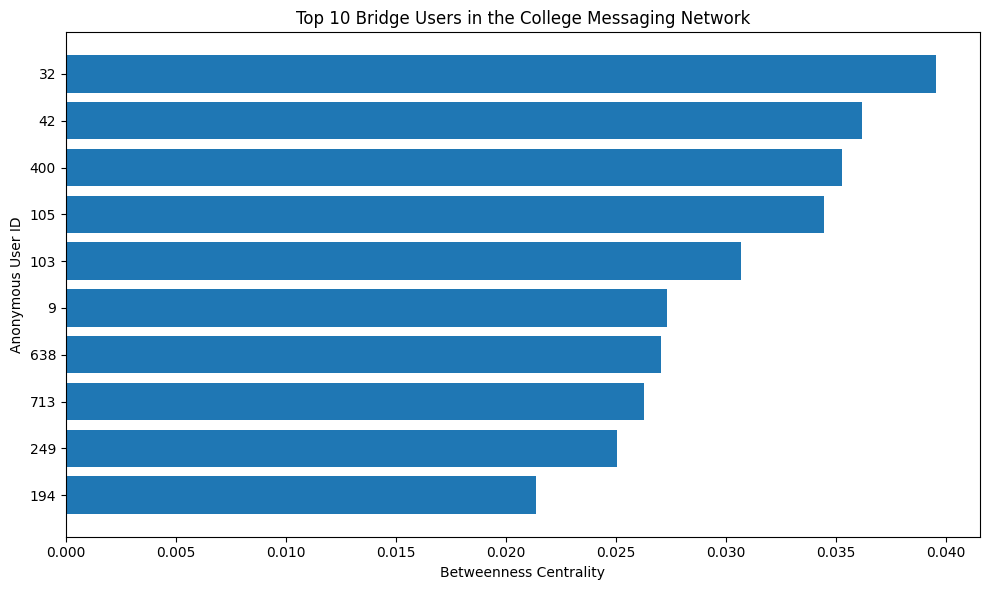

In [32]:
# top 10 bridge users
top10_bridge = results.head(10).sort_values(
    "betweenness",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    top10_bridge["user"].astype(str),
    top10_bridge["betweenness"]
)

plt.xlabel("Betweenness Centrality")
plt.ylabel("Anonymous User ID")
plt.title("Top 10 Bridge Users in the College Messaging Network")
plt.tight_layout()

plt.savefig(
    "top10_betweenness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


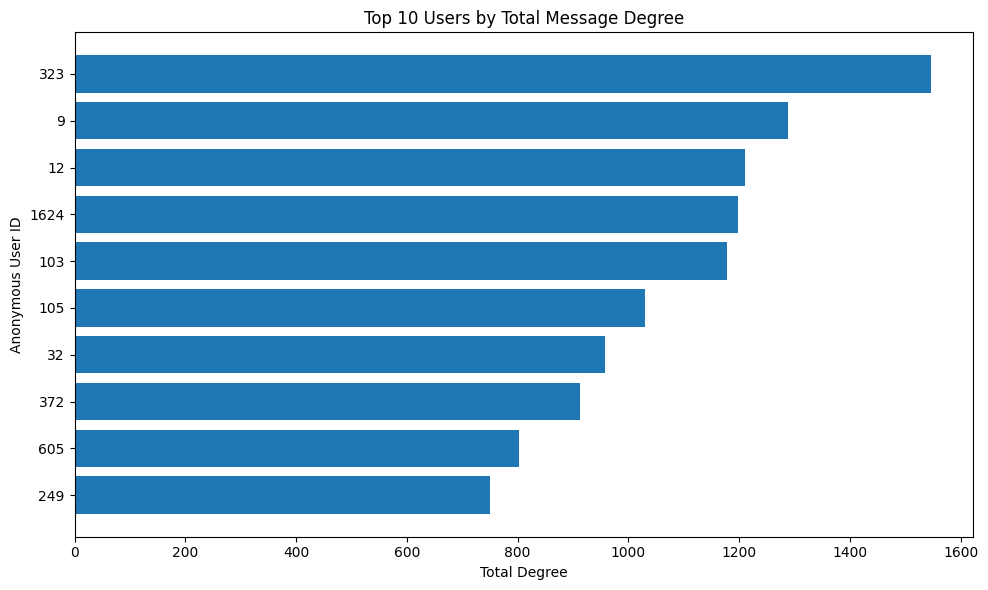

In [33]:
# top 10 users by total degree
top10_degree = degree_results.head(10).sort_values(
    "total_degree",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    top10_degree["user"].astype(str),
    top10_degree["total_degree"]
)

plt.xlabel("Total Degree")
plt.ylabel("Anonymous User ID")
plt.title("Top 10 Users by Total Message Degree")
plt.tight_layout()

plt.savefig(
    "top10_degree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


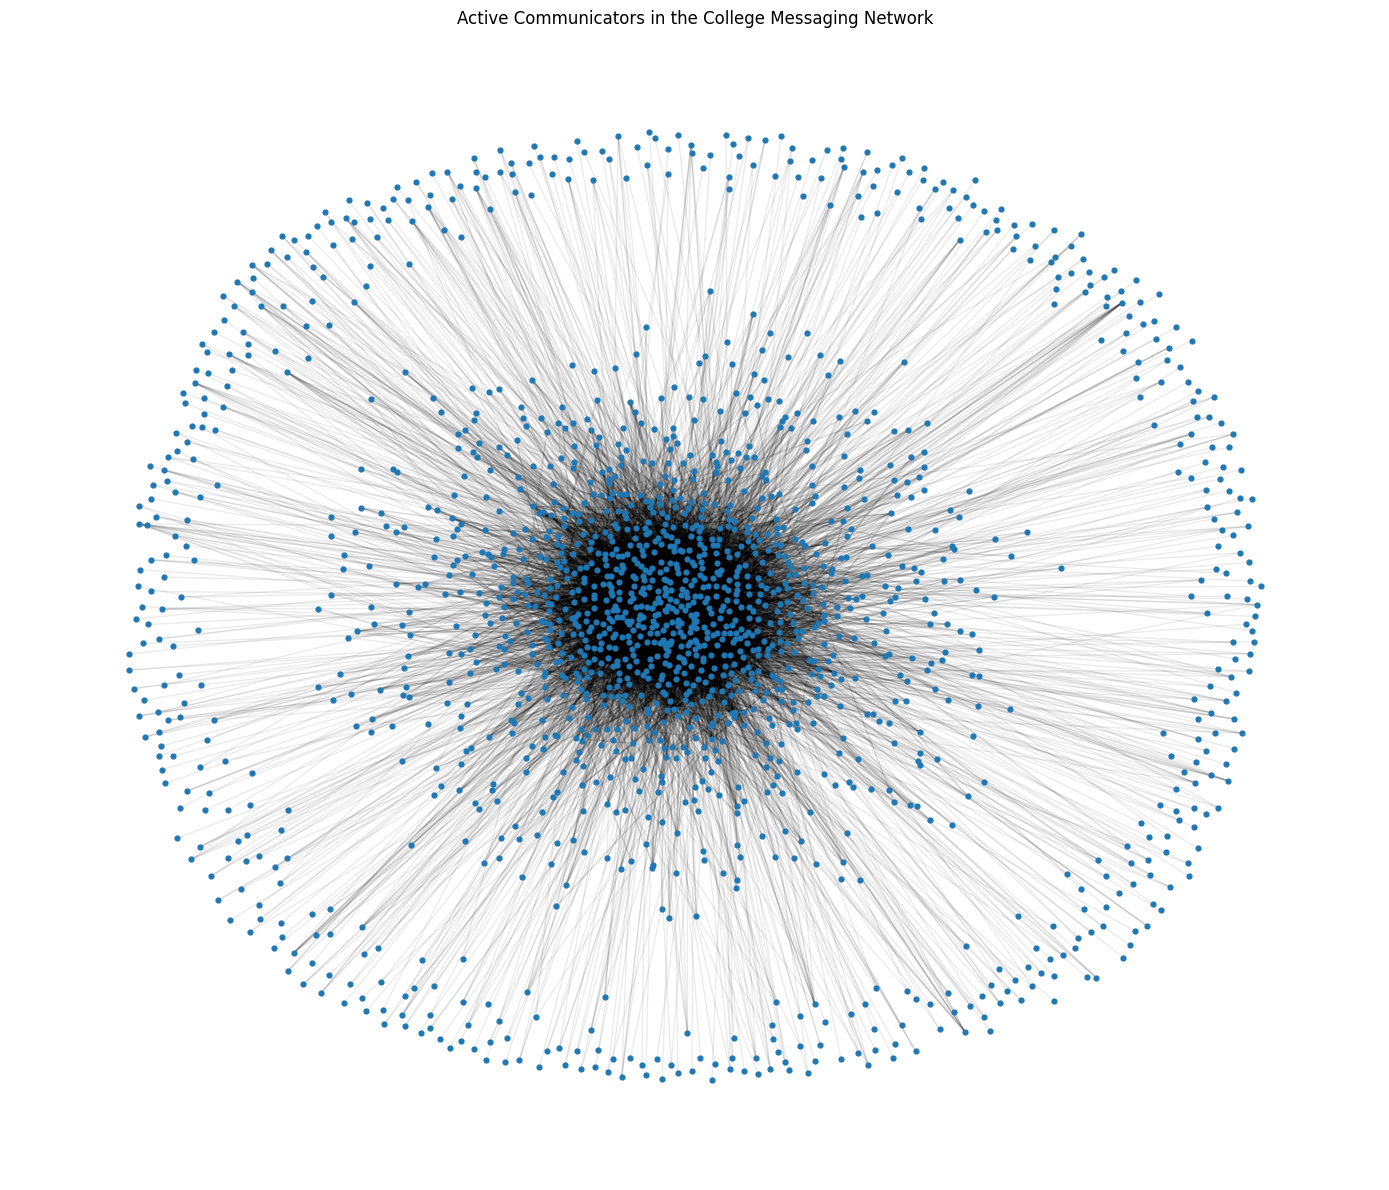

In [34]:

# a simplified network visualization using unique directed relationships.
plt.figure(figsize=(14, 12))

pos = nx.spring_layout(
    G_bridge,
    seed=42,
    k=0.15
)

nx.draw_networkx_nodes(
    G_bridge,
    pos,
    node_size=12
)

nx.draw_networkx_edges(
    G_bridge,
    pos,
    alpha=0.08,
    arrows=False
)

plt.title("Active Communicators in the College Messaging Network")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    "college_network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [35]:

results.head(10).to_csv(
    "top10_bridge_users.csv",
    index=False
)

degree_results.head(10).to_csv(
    "top10_degree_users.csv",
    index=False
)



## 14. Validation notes

Check that:

- the full graph has 1,899 nodes;
- the input contains 59,835 messages;
- the date range spans about 193 days;
- the active-sender filter returns roughly 298 users who sent at least 50 messages;
- the most important users are plausible given their degree and network positions.

A separate public teaching analysis of this dataset found Users 32, 103, and 105 among the highest-betweenness users in a similarly defined active-communicator network. If your exact Python ranking differs slightly, report your Python results rather than forcing them to match; differences can result from how repeated messages are handled.
